<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day35_Imbalanced_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             precision_recall_curve, roc_curve, average_precision_score)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.combine import SMOTETomek, SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

Accuracy is useless whene classes are imbalanced

In [ ]:
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


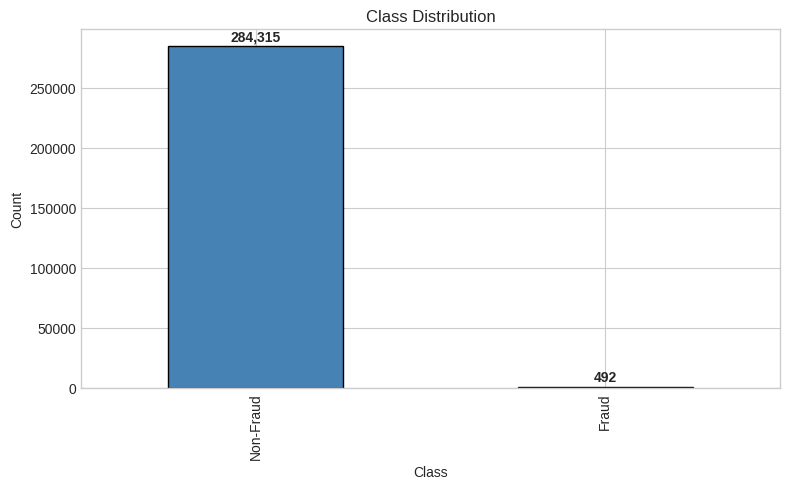

In [ ]:
print("Class Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")

fig, ax = plt.subplots(figsize=(8, 5))
df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black', ax=ax)
ax.set_xticklabels(['Non-Fraud', 'Fraud'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')

#Add count labels
for i, v, in enumerate(df['Class'].value_counts()):
  ax.text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#Features are already PCA-Transformed (V1-V28) for privacy
x = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
x['Amount'] = scaler.fit_transform(x[['Amount']])
x['Time'] = scaler.fit_transform(x[['Time']])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

Train set shape: (227845, 30)
Test set shape: (56962, 30)


Baseline Model

In [ ]:
baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(x_train, y_train)

y_pred_base = baseline.predict(x_test)
y_prob_base = baseline.predict_proba(x_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_base):.4f}")


Accuracy: 0.9992
Precision: 0.8289
Recall: 0.6429
F1 Score: 0.7241
ROC AUC: 0.9573


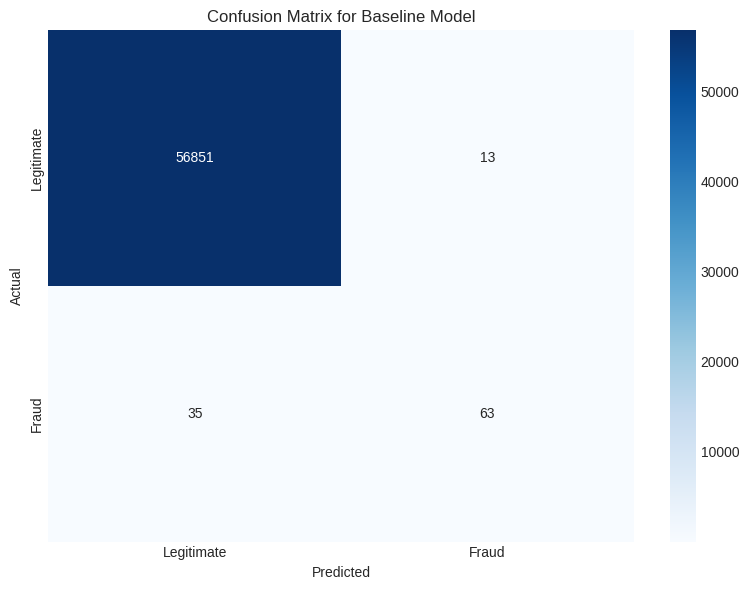

True Negatives: 56851
False Positives: 13
False Negatives: 35
True Positives: 63


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
  plt.title(title)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(title)
  plt.tight_layout()
  plt.show()

  tn, fp, fn, tp = cm.ravel()
  print(f"True Negatives: {tn}")
  print(f"False Positives: {fp}")
  print(f"False Negatives: {fn}")
  print(f"True Positives: {tp}")

plot_confusion_matrix(y_test, y_pred_base, "Confusion Matrix for Baseline Model")
#

Class Weights

In [ ]:
model_weighted = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model_weighted.fit(x_train, y_train)

y_pred_weighted = model_weighted.predict(x_test)
y_prob_weighted = model_weighted.predict_proba(x_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_weighted):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_weighted):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_weighted):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_weighted):.4f}")

Accuracy: 0.9755
Precision: 0.0609
Recall: 0.9184
F1 Score: 0.1141
ROC AUC: 0.9722


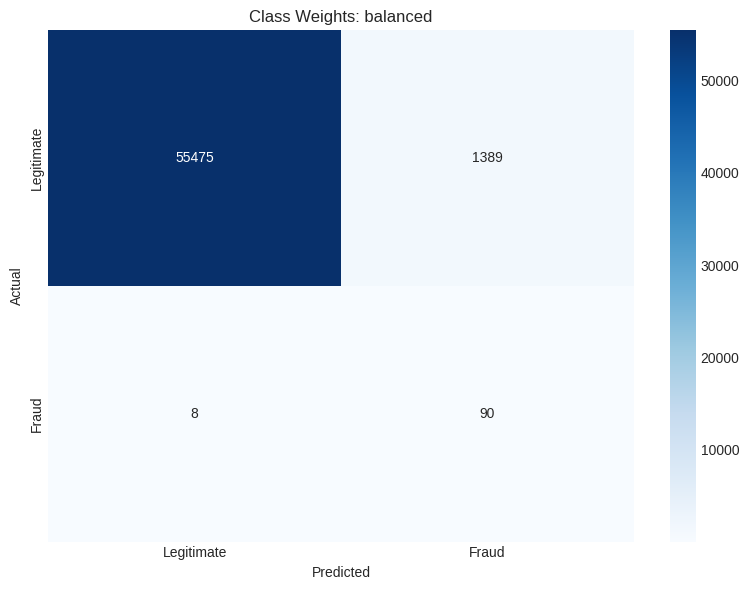

True Negatives: 55475
False Positives: 1389
False Negatives: 8
True Positives: 90


In [ ]:
plot_confusion_matrix(y_test, y_pred_weighted, 'Class Weights: balanced')

Random undersampling

In [ ]:
rus = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

print(f"Before Undersampling: {len(x_train)}")
print(f"After Undersampling: {len(x_train_under)}")
print(f"New class distribution: {pd.Series(y_train_under).value_counts()}")
#

Before Undersampling: 227845
After Undersampling: 788
New class distribution: Class
0    394
1    394
Name: count, dtype: int64


In [ ]:
#Training on undersampled data
model_under = LogisticRegression(random_state=42, max_iter=1000)
model_under.fit(x_train_under, y_train_under)

y_pred_under = model_under.predict(x_test)
y_prob_under = model_under.predict_proba(x_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_under):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_under):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_under):.4}")
print(f"F1 Score: {f1_score(y_test, y_pred_under):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_under):.4f}")

Accuracy: 0.9603
Precision: 0.0384
Recall: 0.9184
F1 Score: 0.0738
ROC AUC: 0.9760


SMOTE(Oversampling)

In [ ]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Before SMOTE: {len(x_train)}")
print(f"After SMOTE: {len(x_train_smote)}")
print(f"New class distribution: {pd.Series(y_train_smote).value_counts()}")


Before SMOTE: 227845
After SMOTE: 454902
New class distribution: Class
0    227451
1    227451
Name: count, dtype: int64


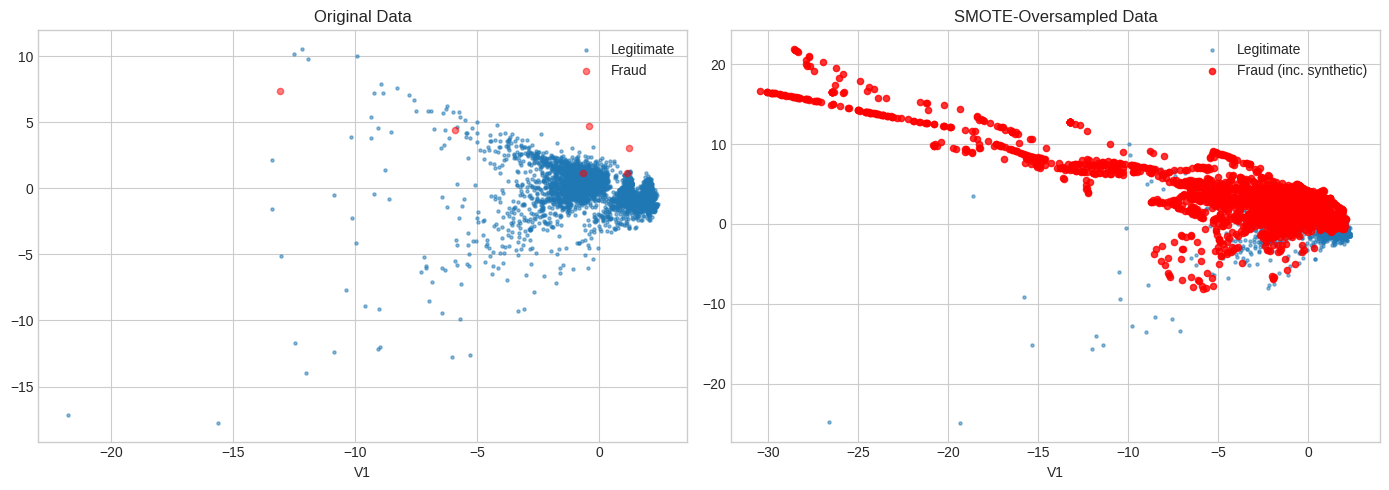

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.random.choice(len(x_train), 5000, replace=False)
x_sample = x_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

axes[0].scatter(x_sample[y_sample==0]['V1'], x_sample[y_sample==0]['V2'], alpha=0.5, s=5, label='Legitimate')
axes[0].scatter(x_sample[y_sample==1]['V1'], x_sample[y_sample==1]['V2'], alpha=0.5, s=20, c='red', label='Fraud')
axes[0].set_title('Original Data')
axes[0].set_xlabel('V1')
axes[0].legend()

#After SMOTE
x_train_smote_df = pd.DataFrame(x_train_smote, columns=x_train.columns)
sample_idx2 = np.random.choice(len(x_train_smote_df), 5000, replace=False)
x_sample2 = x_train_smote_df.iloc[sample_idx2]
y_sample2 = y_train_smote.iloc[sample_idx2]

axes[1].scatter(x_sample2[y_sample2==0]['V1'], x_sample2[y_sample2==0]['V2'], alpha=0.5, s=5, label='Legitimate')
axes[1].scatter(x_sample2[y_sample2==1]['V1'], x_sample2[y_sample2==1]['V2'], alpha=0.8, s=20, c='red', label='Fraud (inc. synthetic)')
axes[1].set_title('SMOTE-Oversampled Data')
axes[1].set_xlabel('V1')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Training on the SMOTE Data
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(x_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(x_test)
y_prob_smote = model_smote.predict_proba(x_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_smote):.4f}")

Accuracy: 0.9743
Precision: 0.0581
Recall: 0.9184
F1 Score: 0.1094
ROC AUC: 0.9698


smote variants

In [ ]:
smote_variants = {
    'SMOTE': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

smote_results = []

for name, sampler in smote_variants.items():
  try:
    x_res, y_res = sampler.fit_resample(x_train, y_train)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(x_res, y_res)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    smote_results.append({
        'Method': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

    print(f"{name:<20} F1: {f1_score(y_test, y_pred):.4f} Recall: {recall_score(y_test, y_pred):.4f}")
  except Exception as e:
    print(f"{name:<20} Error: {e}")

smote_df = pd.DataFrame(smote_results)

SMOTE                F1: 0.1094 Recall: 0.9184
BorderlineSMOTE      F1: 0.1627 Recall: 0.8673
ADASYN               F1: 0.0355 Recall: 0.9184


## Summary

### Techniques Covered

| Technique | Pros | Cons |
|-----------|------|------|
| Class Weights | Simple, no data change | Limited improvement |
| Undersampling | Fast, reduces data | Loses information |
| SMOTE | Creates useful samples | Can create noise |
| Threshold Tuning | Fine control | Need to choose metric |

### Key Metrics for Imbalanced Data

| Metric | Use When |
|--------|----------|
| **Recall** | Missing fraud is very costly |
| **Precision** | False alarms are costly |
| **F1** | Balance both |
| **ROC-AUC** | Overall model quality |
| **PR-AUC** | Very imbalanced data |

### Golden Rules

1. **Never use accuracy** on imbalanced data
2. **Only resample training data** — never test!
3. **Stratify your splits**
4. **Consider business costs** — not just metrics